In [1]:
import matplotlib.pyplot as plt
%matplotlib widget

In [15]:
import numpy as np
from scipy.sparse import coo_matrix

def discretise_poisson(N):
    """Generate the matrix and rhs associated with the discrete Poisson operator."""

    rows = []
    columns = []
    data = []

    f = np.empty(N * N, dtype=np.float64)

    diagonal = 4 * (N - 1)**2
    off_diagonal = -(N - 1)**2
    
    for j in range(N):
        for i in range(N):
            if i == 0 or i == N - 1 or j == 0 or j == N - 1:
                rows.append(j * N + i)
                columns.append(j * N + i)
                data.append(1)
                f[j * N + i] = 0
                
            else:
                rows.append(j * N + i)
                columns.append(j * N + i)
                data.append(diagonal)
                
                rows.append(j * N + i)
                columns.append(j * N + i + 1)
                data.append(off_diagonal)     

                rows.append(j * N + i)
                columns.append(j * N + i - 1)
                data.append(off_diagonal)  

                rows.append(j * N + i)
                columns.append((j+1) * N + i)
                data.append(off_diagonal)

                rows.append(j * N + i)
                columns.append((j-1) * N + i)
                data.append(off_diagonal)
                
                f[j * N + i] = 1
                
    row_ind = np.array(rows)
    col_ind = np.array(columns)
    data = np.array(data)
    return coo_matrix((data, (row_ind, col_ind)), shape=(N**2, N**2)).tocsr(), f

In [18]:
A, f = discretise_poisson(100)

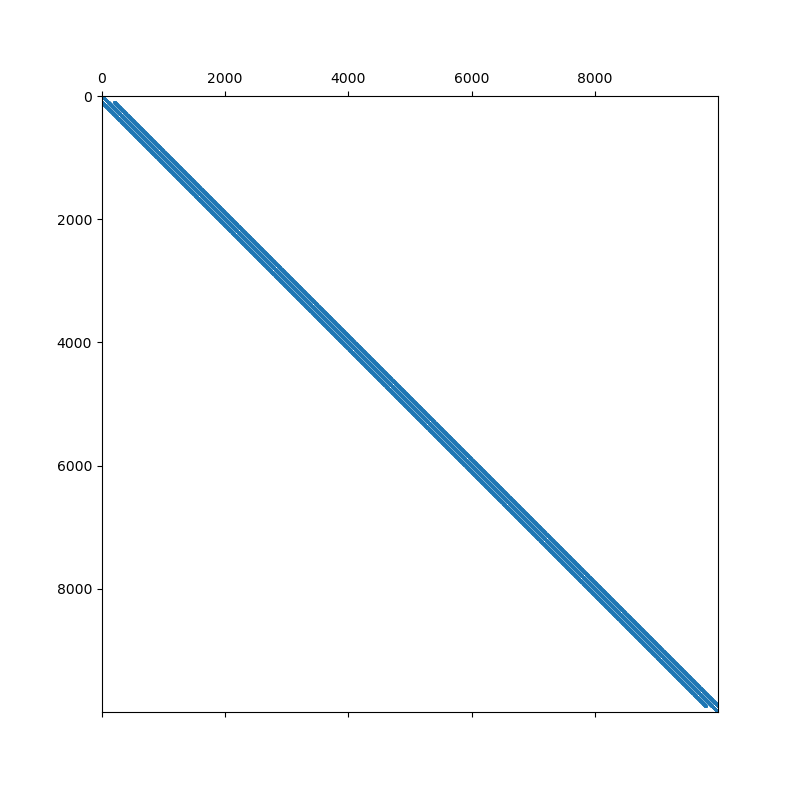

In [19]:


plt.figure(figsize=(8, 8))
plt.spy(A, markersize=1)

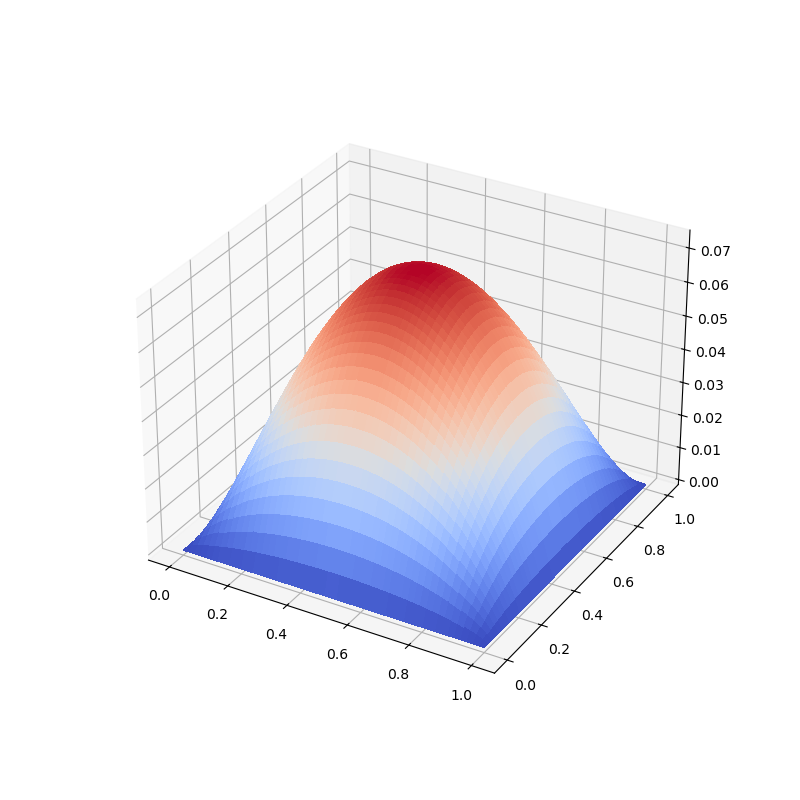

In [20]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

from scipy.sparse.linalg import spsolve

N = 200

A, f = discretise_poisson(N)
sol = spsolve(A, f)

u = sol.reshape((N, N))

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
ticks= np.linspace(0, 1, N)
X, Y = np.meshgrid(ticks, ticks)
surf = ax.plot_surface(X, Y, u, antialiased=False, cmap=cm.coolwarm)
plt.show()

In [21]:
nbytes = A.data.nbytes + A.indices.nbytes + A.indptr.nbytes
print(f"The matrix A uses {round(nbytes / 1024**2, 2)} MB Ram.")

The matrix A uses 2.4 MB Ram.


In [24]:
nbytes = np.prod(A.shape)*8

print(f"The matrix dense version would use {round(nbytes / 1024**3, 2)} GB Ram.")

The matrix dense version would use 11.92 GB Ram.
